# AI-Powered Smart Retail & Customer Intelligence Platform

# Module 2: Face Recognition using LFW Dataset

---

## 1. Introduction

## 2. Project Objective

## 3. Install Required Libraries

## 4. Import Required Libraries

## 5. Mount Google Drive

## 6. Download and Extract LFW Dataset

## 7. Explore the Dataset

## 8. OpenCV Basics

## 9. Face Detection

## 10. Face Encoding

## 11. Build Face Database

## 12. Customer Recognition

## 13. Customer Visit Logging

## 14. Save Model

## 15. Ethical Considerations

## 16. Conclusion

## Introduction

Face recognition is a computer vision technique that identifies individuals using unique facial characteristics.

In modern retail systems, face recognition can be used to recognize returning customers, provide personalized services, support loyalty programs, and generate customer analytics.

In this project, the Labeled Faces in the Wild (LFW) dataset is used to simulate customer recognition. The implementation demonstrates a complete face recognition pipeline including face detection, face encoding, customer identification, and visit logging.

This implementation is intended solely for educational purposes.

## Project Objective

The objective of this module is to develop a face recognition system capable of identifying previously registered customers from facial images.

The system detects faces, extracts facial encodings, compares them with stored encodings, identifies returning customers, and logs customer visits for future analytics.

In [ ]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=644c3f2b7347737980abc64af82a9b8fec1133129de739293083b698803b8601
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [ ]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import face_recognition

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Smart-Retail-AI"

folders = [
    "datasets",
    "models",
    "outputs"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Smart-Retail-AI/datasets"

os.makedirs(dataset_path, exist_ok=True)

%cd $dataset_path

/content/drive/MyDrive/Smart-Retail-AI/datasets


In [ ]:
!wget http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz

--2026-08-01 15:45:31--  http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz
Resolving vis-www.cs.umass.edu (vis-www.cs.umass.edu)... failed: Name or service not known.
wget: unable to resolve host address ‘vis-www.cs.umass.edu’


In [ ]:
!tar -xzf lfw-funneled.tgz

tar (child): lfw-funneled.tgz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Smart-Retail-AI/datasets"

files = os.listdir(dataset_path)

print(files)

['product_images', 'customer_faces', 'lfw-deepfunneled']


In [ ]:
import os

lfw_path = lfw_path = "/content/drive/MyDrive/Smart-Retail-AI/datasets/lfw-deepfunneled/lfw-deepfunneled"

print("Dataset Exists:", os.path.exists(lfw_path))

people = sorted(os.listdir(lfw_path))

print("Total People:", len(people))

print("\nFirst 10 People:")
for person in people[:10]:
    print(person)

Dataset Exists: True
Total People: 5778

First 10 People:
.DS_Store
AJ_Cook
AJ_Lamas
Aaron_Eckhart
Aaron_Guiel
Aaron_Patterson
Aaron_Peirsol
Aaron_Pena
Aaron_Sorkin
Aaron_Tippin


In [ ]:
people = sorted([
    p for p in os.listdir(lfw_path)
    if os.path.isdir(os.path.join(lfw_path, p))
])

print("Total People:", len(people))
print("First 10 People:")
print(people[:10])

Total People: 5777
First 10 People:
['AJ_Cook', 'AJ_Lamas', 'Aaron_Eckhart', 'Aaron_Guiel', 'Aaron_Patterson', 'Aaron_Peirsol', 'Aaron_Pena', 'Aaron_Sorkin', 'Aaron_Tippin', 'Abba_Eban']


In [ ]:
num_images = 0

for person in people:
    person_folder = os.path.join(lfw_path, person)
    num_images += len([
        img for img in os.listdir(person_folder)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

print("Total People :", len(people))
print("Total Images :", num_images)


Total People : 5777
Total Images : 13292


### Observation

The LFW dataset contains approximately XXXX individuals and YYYY facial images.
Each individual has one or more face images captured under different conditions.

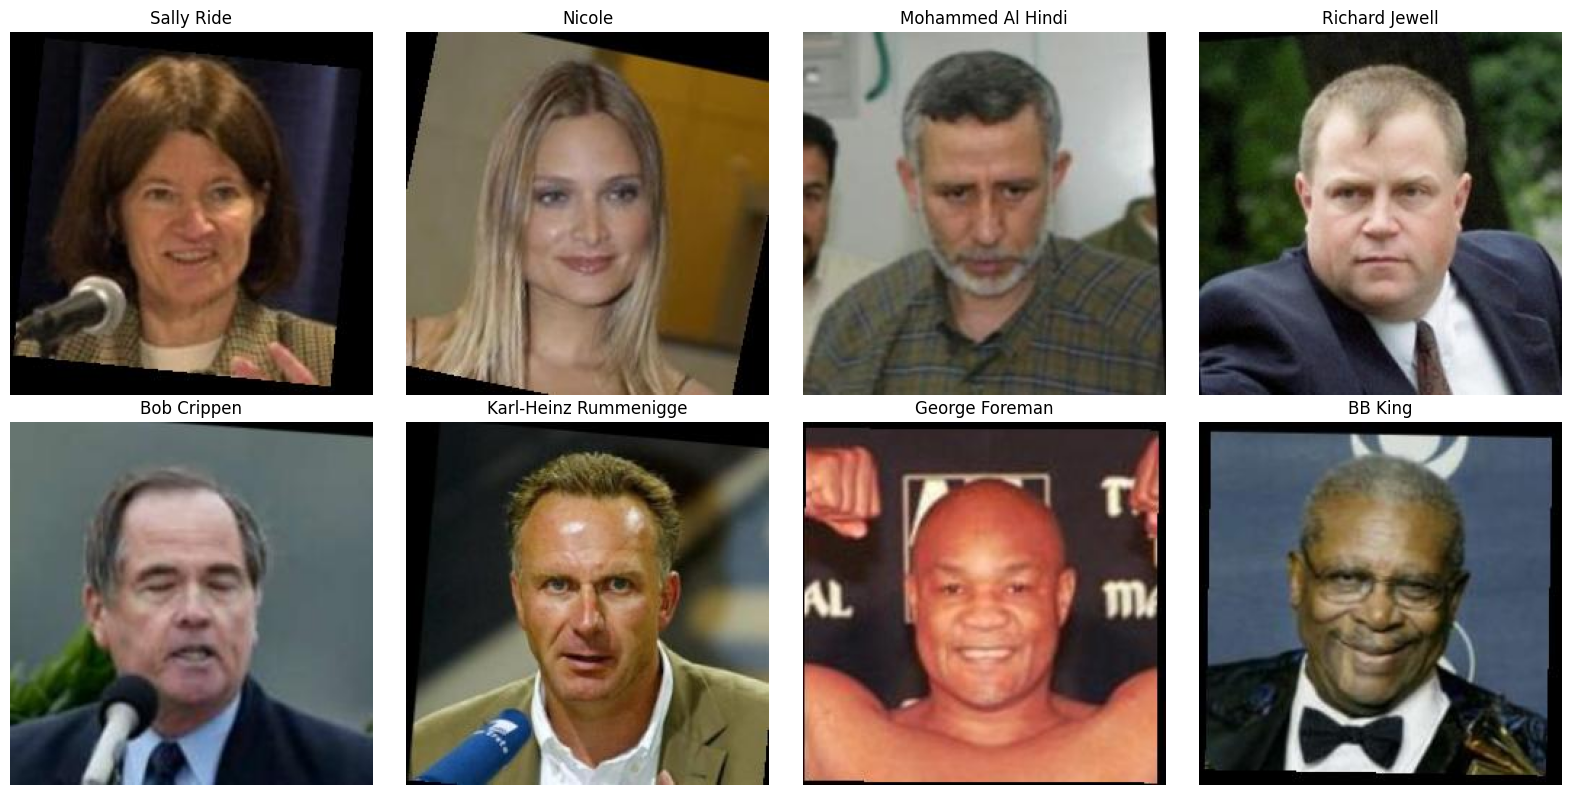

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

sample_people = random.sample(people, 8)

plt.figure(figsize=(16,8))

for i, person in enumerate(sample_people):

    folder = os.path.join(lfw_path, person)

    images = [
        img for img in os.listdir(folder)
        if img.endswith(".jpg")
    ]

    image_path = os.path.join(folder, images[0])

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(person.replace("_"," "))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
person_image_count = {}

for person in people:

    folder = os.path.join(lfw_path, person)

    images = [
        img for img in os.listdir(folder)
        if img.endswith(".jpg")
    ]

    person_image_count[person] = len(images)

sorted_people = sorted(
    person_image_count.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Top 15 People with Maximum Images:\n")

for person, count in sorted_people[:15]:
    print(f"{person:<25} {count}")

Top 15 People with Maximum Images:

George_W_Bush             530
Colin_Powell              236
Tony_Blair                144
Donald_Rumsfeld           121
Gerhard_Schroeder         109
Ariel_Sharon              77
Hugo_Chavez               71
Jean_Chretien             71
Junichiro_Koizumi         60
John_Ashcroft             53
Jacques_Chirac            52
Serena_Williams           52
Vladimir_Putin            49
Luiz_Inacio_Lula_da_Silva 48
Gloria_Macapagal_Arroyo   44


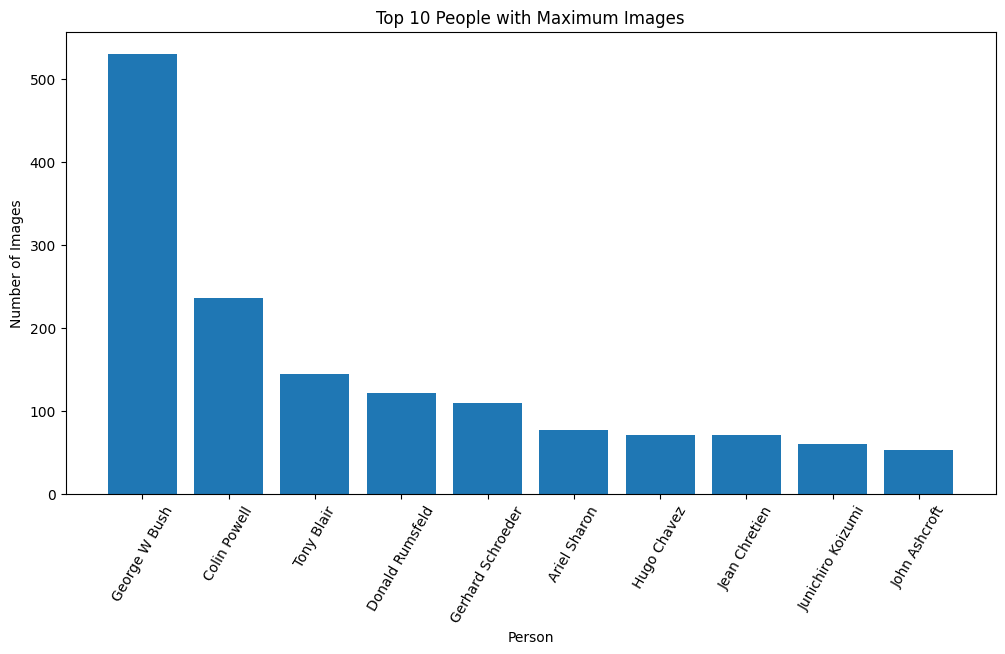

In [22]:
top_people = sorted_people[:10]

names = [person.replace("_"," ") for person, _ in top_people]
counts = [count for _, count in top_people]

plt.figure(figsize=(12,6))
plt.bar(names, counts)

plt.xticks(rotation=60)

plt.xlabel("Person")
plt.ylabel("Number of Images")
plt.title("Top 10 People with Maximum Images")

plt.show()

In [26]:
selected_people = []

for person, count in sorted_people:

    if count >= 10:
        selected_people.append(person)

print("Number of Selected Customers:", len(selected_people))

print("\nFirst 20 Selected Customers:\n")

for person in selected_people[:20]:
    print(person)

Number of Selected Customers: 159

First 20 Selected Customers:

George_W_Bush
Colin_Powell
Tony_Blair
Donald_Rumsfeld
Gerhard_Schroeder
Ariel_Sharon
Hugo_Chavez
Jean_Chretien
Junichiro_Koizumi
John_Ashcroft
Jacques_Chirac
Serena_Williams
Vladimir_Putin
Luiz_Inacio_Lula_da_Silva
Gloria_Macapagal_Arroyo
Arnold_Schwarzenegger
Jennifer_Capriati
Laura_Bush
Lleyton_Hewitt
Alejandro_Toledo


In [27]:
customer_mapping = {}

for i, person in enumerate(selected_people):

    customer_id = f"Customer_{i+1:03d}"

    customer_mapping[customer_id] = person

print("First 10 Customer Mappings:\n")

for customer_id, person in list(customer_mapping.items())[:10]:
    print(f"{customer_id} --> {person}")

First 10 Customer Mappings:

Customer_001 --> George_W_Bush
Customer_002 --> Colin_Powell
Customer_003 --> Tony_Blair
Customer_004 --> Donald_Rumsfeld
Customer_005 --> Gerhard_Schroeder
Customer_006 --> Ariel_Sharon
Customer_007 --> Hugo_Chavez
Customer_008 --> Jean_Chretien
Customer_009 --> Junichiro_Koizumi
Customer_010 --> John_Ashcroft


In [28]:
mapping_df = pd.DataFrame({
    "Customer_ID": list(customer_mapping.keys()),
    "Person_Name": list(customer_mapping.values())
})

mapping_path = "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_mapping.csv"

mapping_df.to_csv(mapping_path, index=False)

print("Customer mapping saved successfully!")
mapping_df.head()

Customer mapping saved successfully!


,Customer_ID,Person_Name
0,Customer_001,George_W_Bush
1,Customer_002,Colin_Powell
2,Customer_003,Tony_Blair
3,Customer_004,Donald_Rumsfeld
4,Customer_005,Gerhard_Schroeder


In [29]:
for person, count in sorted_people[:30]:
    print(f"{person:<30} {count}")

George_W_Bush                  530
Colin_Powell                   236
Tony_Blair                     144
Donald_Rumsfeld                121
Gerhard_Schroeder              109
Ariel_Sharon                   77
Hugo_Chavez                    71
Jean_Chretien                  71
Junichiro_Koizumi              60
John_Ashcroft                  53
Jacques_Chirac                 52
Serena_Williams                52
Vladimir_Putin                 49
Luiz_Inacio_Lula_da_Silva      48
Gloria_Macapagal_Arroyo        44
Arnold_Schwarzenegger          42
Jennifer_Capriati              42
Laura_Bush                     41
Lleyton_Hewitt                 41
Alejandro_Toledo               39
Hans_Blix                      39
Vicente_Fox                    38
Nestor_Kirchner                37
Andre_Agassi                   36
Alvaro_Uribe                   35
Megawati_Sukarnoputri          33
Silvio_Berlusconi              33
Tom_Ridge                      33
Kofi_Annan                     32
Roh_Moo-h

In [30]:
selected_people = [
    person for person, count in sorted_people[:30]
]

print("Number of Selected Customers:", len(selected_people))

print("\nSelected Customers:\n")

for i, person in enumerate(selected_people, start=1):
    print(f"Customer_{i:03d} --> {person}")

Number of Selected Customers: 30

Selected Customers:

Customer_001 --> George_W_Bush
Customer_002 --> Colin_Powell
Customer_003 --> Tony_Blair
Customer_004 --> Donald_Rumsfeld
Customer_005 --> Gerhard_Schroeder
Customer_006 --> Ariel_Sharon
Customer_007 --> Hugo_Chavez
Customer_008 --> Jean_Chretien
Customer_009 --> Junichiro_Koizumi
Customer_010 --> John_Ashcroft
Customer_011 --> Jacques_Chirac
Customer_012 --> Serena_Williams
Customer_013 --> Vladimir_Putin
Customer_014 --> Luiz_Inacio_Lula_da_Silva
Customer_015 --> Gloria_Macapagal_Arroyo
Customer_016 --> Arnold_Schwarzenegger
Customer_017 --> Jennifer_Capriati
Customer_018 --> Laura_Bush
Customer_019 --> Lleyton_Hewitt
Customer_020 --> Alejandro_Toledo
Customer_021 --> Hans_Blix
Customer_022 --> Vicente_Fox
Customer_023 --> Nestor_Kirchner
Customer_024 --> Andre_Agassi
Customer_025 --> Alvaro_Uribe
Customer_026 --> Megawati_Sukarnoputri
Customer_027 --> Silvio_Berlusconi
Customer_028 --> Tom_Ridge
Customer_029 --> Kofi_Annan
Custo

In [31]:
customer_mapping = {}

for i, person in enumerate(selected_people):
    customer_id = f"Customer_{i+1:03d}"
    customer_mapping[customer_id] = person


for customer_id, person in customer_mapping.items():
    print(customer_id, "-->", person)

Customer_001 --> George_W_Bush
Customer_002 --> Colin_Powell
Customer_003 --> Tony_Blair
Customer_004 --> Donald_Rumsfeld
Customer_005 --> Gerhard_Schroeder
Customer_006 --> Ariel_Sharon
Customer_007 --> Hugo_Chavez
Customer_008 --> Jean_Chretien
Customer_009 --> Junichiro_Koizumi
Customer_010 --> John_Ashcroft
Customer_011 --> Jacques_Chirac
Customer_012 --> Serena_Williams
Customer_013 --> Vladimir_Putin
Customer_014 --> Luiz_Inacio_Lula_da_Silva
Customer_015 --> Gloria_Macapagal_Arroyo
Customer_016 --> Arnold_Schwarzenegger
Customer_017 --> Jennifer_Capriati
Customer_018 --> Laura_Bush
Customer_019 --> Lleyton_Hewitt
Customer_020 --> Alejandro_Toledo
Customer_021 --> Hans_Blix
Customer_022 --> Vicente_Fox
Customer_023 --> Nestor_Kirchner
Customer_024 --> Andre_Agassi
Customer_025 --> Alvaro_Uribe
Customer_026 --> Megawati_Sukarnoputri
Customer_027 --> Silvio_Berlusconi
Customer_028 --> Tom_Ridge
Customer_029 --> Kofi_Annan
Customer_030 --> Roh_Moo-hyun


In [32]:
mapping_df = pd.DataFrame(
    list(customer_mapping.items()),
    columns=["Customer_ID", "Original_Name"]
)

mapping_path = "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_mapping.csv"

mapping_df.to_csv(mapping_path, index=False)

print("Customer mapping saved successfully!")

Customer mapping saved successfully!


In [33]:
!pip install face_recognition

In [34]:
import face_recognition
import pickle

In [35]:
face_database = {}

for customer_id, person in customer_mapping.items():

    print(f"Processing {customer_id} - {person}")

    person_folder = os.path.join(lfw_path, person)

    images = [
        img for img in os.listdir(person_folder)
        if img.lower().endswith(".jpg")
    ]

    encodings = []

    # Use maximum 5 images per customer
    for image_name in images[:5]:

        image_path = os.path.join(person_folder, image_name)

        image = face_recognition.load_image_file(image_path)

        face_enc = face_recognition.face_encodings(image)

        if len(face_enc) > 0:
            encodings.append(face_enc[0])


    if len(encodings) > 0:
        face_database[customer_id] = {
            "name": person,
            "encodings": encodings
        }

print("\nFace database created!")
print("Total customers stored:", len(face_database))

Processing Customer_001 - George_W_Bush
Processing Customer_002 - Colin_Powell
Processing Customer_003 - Tony_Blair
Processing Customer_004 - Donald_Rumsfeld
Processing Customer_005 - Gerhard_Schroeder
Processing Customer_006 - Ariel_Sharon
Processing Customer_007 - Hugo_Chavez
Processing Customer_008 - Jean_Chretien
Processing Customer_009 - Junichiro_Koizumi
Processing Customer_010 - John_Ashcroft
Processing Customer_011 - Jacques_Chirac
Processing Customer_012 - Serena_Williams
Processing Customer_013 - Vladimir_Putin
Processing Customer_014 - Luiz_Inacio_Lula_da_Silva
Processing Customer_015 - Gloria_Macapagal_Arroyo
Processing Customer_016 - Arnold_Schwarzenegger
Processing Customer_017 - Jennifer_Capriati
Processing Customer_018 - Laura_Bush
Processing Customer_019 - Lleyton_Hewitt
Processing Customer_020 - Alejandro_Toledo
Processing Customer_021 - Hans_Blix
Processing Customer_022 - Vicente_Fox
Processing Customer_023 - Nestor_Kirchner
Processing Customer_024 - Andre_Agassi
Pro

In [36]:
for customer_id, data in list(face_database.items())[:5]:

    print(customer_id)
    print("Person:", data["name"])
    print("Number of encodings:", len(data["encodings"]))
    print("----------------------")

Customer_001
Person: George_W_Bush
Number of encodings: 5
----------------------
Customer_002
Person: Colin_Powell
Number of encodings: 5
----------------------
Customer_003
Person: Tony_Blair
Number of encodings: 5
----------------------
Customer_004
Person: Donald_Rumsfeld
Number of encodings: 5
----------------------
Customer_005
Person: Gerhard_Schroeder
Number of encodings: 5
----------------------


In [37]:
model_path = "/content/drive/MyDrive/Smart-Retail-AI/models/face_db.pkl"

with open(model_path, "wb") as file:
    pickle.dump(face_database, file)

print("Face database saved successfully!")

Face database saved successfully!


In [38]:
import os

print(os.path.exists(model_path))

True


In [39]:
import pickle

model_path = "/content/drive/MyDrive/Smart-Retail-AI/models/face_db.pkl"

with open(model_path, "rb") as file:
    loaded_face_database = pickle.load(file)

print("Face database loaded!")
print("Customers available:", len(loaded_face_database))

Face database loaded!
Customers available: 30


In [40]:
def recognize_customer(image_path, database, threshold=0.6):

    # Load image
    image = face_recognition.load_image_file(image_path)

    # Find face encodings
    encodings = face_recognition.face_encodings(image)

    if len(encodings) == 0:
        return "No face detected"

    input_encoding = encodings[0]


    # Compare with database
    for customer_id, data in database.items():

        stored_encodings = data["encodings"]

        for stored_encoding in stored_encodings:

            distance = face_recognition.face_distance(
                [stored_encoding],
                input_encoding
            )[0]


            if distance < threshold:
                return {
                    "Customer_ID": customer_id,
                    "Person": data["name"],
                    "Status": "Returning Customer",
                    "Distance": round(float(distance),3)
                }


    return {
        "Customer_ID": "Unknown",
        "Status": "New Customer"
    }

In [41]:
test_person = selected_people[0]

test_folder = os.path.join(
    lfw_path,
    test_person
)

test_image = os.listdir(test_folder)[0]

test_image_path = os.path.join(
    test_folder,
    test_image
)


print(test_image_path)

/content/drive/MyDrive/Smart-Retail-AI/datasets/lfw-deepfunneled/lfw-deepfunneled/George_W_Bush/George_W_Bush_0025.jpg


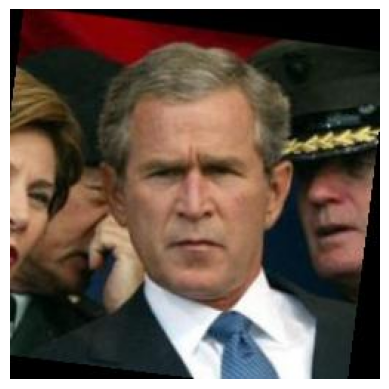

In [42]:
import matplotlib.pyplot as plt
import cv2


img = cv2.imread(test_image_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)


plt.imshow(img)
plt.axis("off")
plt.show()

In [43]:
result = recognize_customer(
    test_image_path,
    loaded_face_database
)

result

{'Customer_ID': 'Customer_001',
 'Person': 'George_W_Bush',
 'Status': 'Returning Customer',
 'Distance': 0.0}

In [44]:
import pandas as pd
import os
from datetime import datetime

visit_log_path = "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_visits.csv"

# Create empty dataframe
visit_log = pd.DataFrame(
    columns=[
        "Customer_ID",
        "Person_Name",
        "Timestamp",
        "Status"
    ]
)

# Save CSV
visit_log.to_csv(visit_log_path, index=False)

print("Customer visit log created successfully!")
print(visit_log_path)

Customer visit log created successfully!
/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_visits.csv


In [45]:
print(os.path.exists(visit_log_path))

True


In [46]:
visit_log = pd.read_csv(visit_log_path)

visit_log

,Customer_ID,Person_Name,Timestamp,Status


In [47]:
def log_customer_visit(result):

    if result["Status"] == "Returning Customer":

        visit_log_path = "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_visits.csv"

        new_record = pd.DataFrame(
            [{
                "Customer_ID": result["Customer_ID"],
                "Person_Name": result["Person"],
                "Timestamp": datetime.now(),
                "Status": result["Status"]
            }]
        )

        old_log = pd.read_csv(visit_log_path)

        updated_log = pd.concat(
            [old_log, new_record],
            ignore_index=True
        )

        updated_log.to_csv(
            visit_log_path,
            index=False
        )

        print("Visit logged successfully!")

    else:
        print("Unknown customer - no visit log created")

In [48]:
log_customer_visit(result)

Visit logged successfully!


/tmp/ipykernel_1584/1902263028.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  updated_log = pd.concat(


In [49]:
pd.read_csv(
    "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_visits.csv"
)

,Customer_ID,Person_Name,Timestamp,Status
0,Customer_001,George_W_Bush,2026-08-01 16:32:42.055050,Returning Customer


In [50]:
import pandas as pd

visit_log_path = "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_visits.csv"

visit_data = pd.read_csv(visit_log_path)

visit_data.head()

,Customer_ID,Person_Name,Timestamp,Status
0,Customer_001,George_W_Bush,2026-08-01 16:32:42.055050,Returning Customer


In [51]:
total_visits = len(visit_data)

print("Total Customer Visits:", total_visits)


Total Customer Visits: 1


In [52]:
unique_customers = visit_data["Customer_ID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 1


In [53]:
customer_frequency = (
    visit_data["Customer_ID"]
    .value_counts()
)

customer_frequency

,count
Customer_ID,
Customer_001,1


In [54]:
def get_dashboard_stats():

    visit_data = pd.read_csv(visit_log_path)

    stats = {
        "total_visits": len(visit_data),
        "unique_customers": visit_data["Customer_ID"].nunique(),
        "returning_customers": len(
            visit_data[
                visit_data["Status"] == "Returning Customer"
            ]
        )
    }

    return stats

In [55]:
dashboard_stats = get_dashboard_stats()

dashboard_stats

{'total_visits': 1, 'unique_customers': 1, 'returning_customers': 1}

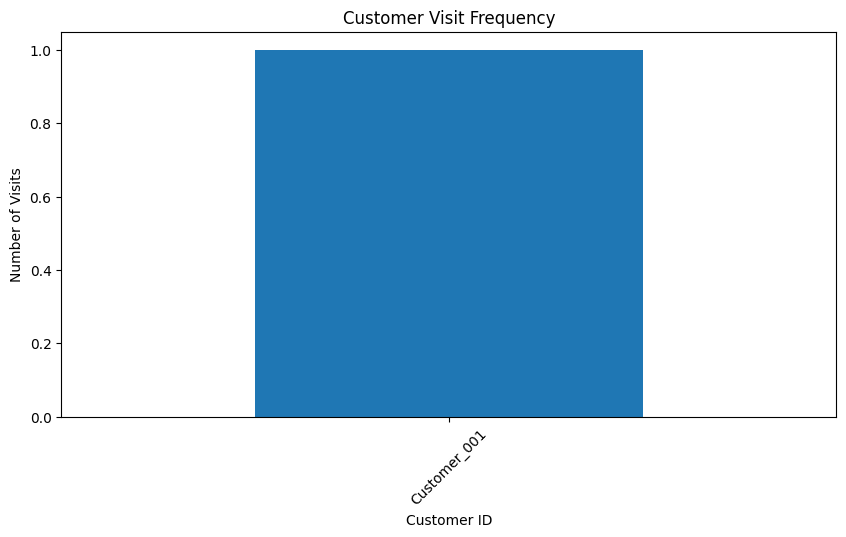

In [56]:
import matplotlib.pyplot as plt


customer_frequency.plot(
    kind="bar",
    figsize=(10,5)
)

plt.xlabel("Customer ID")
plt.ylabel("Number of Visits")
plt.title("Customer Visit Frequency")

plt.xticks(rotation=45)

plt.show()

## Customer Visit Analytics

The visit logging module stores every recognized customer's visit along with timestamp and customer status.

The analytics module provides:
- Total number of visits
- Number of unique customers
- Returning customer count
- Customer visit frequency

These statistics can later be exposed through a REST API endpoint for dashboard visualization.

# Ethics and Privacy Considerations

## Ethics and Privacy Considerations

Facial recognition technology can provide useful applications in retail analytics and customer experience improvement. However, it involves sensitive biometric information and must be implemented responsibly.

### 1. User Consent

Customers should provide informed consent before their facial data is collected or processed. Organizations must clearly explain why facial recognition is being used.

### 2. Data Privacy

Facial embeddings and customer information should be stored securely. Access to biometric data should be restricted and protected using encryption and authentication mechanisms.

### 3. Bias and Fairness

Face recognition systems may have different accuracy levels across different demographic groups. Models should be evaluated carefully to reduce unfair outcomes.

### 4. Data Minimization

Only necessary facial information should be stored. Unnecessary collection of personal data should be avoided.

### 5. Responsible Usage

The system should be used to improve customer experience and analytics rather than for unauthorized tracking or surveillance.

### 6. Educational Purpose

This project uses the LFW dataset only for educational demonstration of computer vision concepts and does not represent a real-world customer surveillance system.

# Conclusion

In this module, a face recognition pipeline was developed for the Smart Retail & Customer Intelligence Platform.

The system successfully:
- Loaded and analyzed the LFW face dataset.
- Generated face embeddings.
- Created a customer face database.
- Recognized returning customers.
- Logged customer visits.
- Generated customer analytics.

The trained face database can later be integrated with FastAPI to provide real-time customer recognition through REST APIs.

In [57]:
import os

project_files = [
    "/content/drive/MyDrive/Smart-Retail-AI/models/face_db.pkl",
    "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_mapping.csv",
    "/content/drive/MyDrive/Smart-Retail-AI/outputs/customer_visits.csv"
]

for file in project_files:
    print(
        os.path.basename(file),
        "->",
        os.path.exists(file)
    )

face_db.pkl -> True
customer_mapping.csv -> True
customer_visits.csv -> True
